In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torchaudio.transforms as T

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import librosa
import librosa.display

from sklearn.model_selection import StratifiedKFold, train_test_split
import os
from collections import Counter
from torch.utils.data import WeightedRandomSampler
import re
import time
import warnings
import random
from tqdm import tqdm
from pathlib import Path
import pickle

In [5]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [6]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Available GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
CUDA Version: 12.8
Available GPU memory: 23.99 GB


In [7]:
PHYSIONET_PATH = "classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0"  
KAGGLE_PATH = "Kaggle-PASCAL"           

In [8]:
# Define folder structure for PhysioNet
PHYSIONET_FOLDERS = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']

In [9]:
SAMPLE_RATE = 44100
SEGMENT_DURATION = 5.0  # seconds
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
FIXED_FRAMES = int(np.ceil((SAMPLE_RATE * SEGMENT_DURATION - N_FFT) / HOP_LENGTH)) + 1

In [7]:
# Cell 3: Data Extraction Functions for PhysioNet Dataset
def extract_physionet_data(base_path, folders):
    """
    Extract labeled heart sound data from PhysioNet 2016 dataset.
    Returns: list of tuples (file_path, label)
    Also prints the count of each label.
    """
    data_list = []
    label_list = []

    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found!")
            continue

        print(f"Processing folder: {folder}")

        # Get all .wav files in the folder
        wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

        for wav_file in tqdm(wav_files, desc=f"Processing {folder}"):
            wav_path = os.path.join(folder_path, wav_file)

            # Find corresponding .hea file for label
            hea_file = wav_file.replace('.wav', '.hea')
            hea_path = os.path.join(folder_path, hea_file)

            if os.path.exists(hea_path):
                # Extract label from .hea file
                try:
                    label = None
                    with open(hea_path, 'r') as f:
                        lines = f.readlines()
                        # Look for the label in the header file
                        for line in lines:
                            if line.startswith('#'):
                                if 'Abnormal' in line or 'abnormal' in line:
                                    label = 'Abnormal'
                                    break
                                elif 'Normal' in line or 'normal' in line:
                                    label = 'Normal'
                                    break
                        if label is None:
                            # If no explicit label found, check the last line
                            last_line = lines[-1].strip()
                            if last_line == '1':
                                label = 'Normal'
                            elif last_line == '-1':
                                label = 'Abnormal'
                            else:
                                continue  # Skip files without clear labels

                    if label:
                        data_list.append((wav_path, label))
                        label_list.append(label)

                except Exception as e:
                    print(f"Error reading {hea_path}: {e}")
                    continue

    # Print value counts per label
    print("\nLabel distribution in PhysioNet extraction:")
    label_counts = Counter(label_list)
    for lbl, cnt in label_counts.items():
        print(f"{lbl}: {cnt}")
    print(f"Total: {sum(label_counts.values())}")

    return data_list

In [8]:
# Cell 4: Data Extraction Functions for Kaggle Dataset

def extract_id_from_filename(filename):
    """
    Extract numeric ID and optional suffix from complex Kaggle filenames.
    Examples: 
    - 'extrastole__138_1306762146980_B.wav' -> ('1306762146980', 'B')
    - 'normal__123_1306762146980.wav' -> ('1306762146980', '')
    """
    name = filename.replace('.wav', '')
    pattern = r'(\d{10,})(?:_([A-Z]))?$'
    match = re.search(pattern, name)

    if match:
        return match.group(1), match.group(2) if match.group(2) else ''

    numbers = re.findall(r'\d+', name)
    if numbers:
        return numbers[-1], ''

    return None, ''

def load_kaggle_labels(csv_path):
    """
    Load and process Kaggle dataset labels from CSV file.
    Returns a dictionary mapping the base filename (timestamp-based ID and suffix) to binary labels.
    """
    if not os.path.exists(csv_path):
        print(f"Warning: CSV file {csv_path} not found!")
        return {}

    df = pd.read_csv(csv_path)
    label_dict = {}

    for _, row in df.iterrows():
        fname = str(row['fname']).strip()
        id_, suffix = extract_id_from_filename(fname)
        if id_ is None:
            continue

        label_raw = row['label']
        if pd.isna(label_raw) or label_raw == '':
            continue

        label = str(label_raw).lower().strip()
        binary_label = 'Normal' if label == 'normal' else 'Abnormal'

        label_dict[f"{id_}_{suffix}" if suffix else id_] = binary_label

    return label_dict

def extract_kaggle_data(base_path):
    """
    Extract labeled heart sound data from Kaggle dataset.
    Returns a list of tuples: (file_path, label)
    Also prints the count of each label.
    """
    data_list = []
    label_list = []

    set_a_labels = load_kaggle_labels(os.path.join(base_path, 'set_a.csv'))
    set_b_labels = load_kaggle_labels(os.path.join(base_path, 'set_b.csv'))

    all_labels = {**set_a_labels, **set_b_labels}
    print(f"Loaded {len(all_labels)} labeled entries from Kaggle CSV files.")

    audio_dirs = ['set_a', 'set_b']

    for audio_dir in audio_dirs:
        dir_path = os.path.join(base_path, audio_dir)
        if not os.path.exists(dir_path):
            print(f"Warning: Directory {dir_path} not found!")
            continue

        print(f"Processing audio files in directory: {audio_dir}")

        wav_files = [f for f in os.listdir(dir_path) if f.endswith('.wav')]

        for wav_file in tqdm(wav_files, desc=f"Processing {audio_dir}"):
            id_, suffix = extract_id_from_filename(wav_file)
            if id_ is None:
                continue

            file_key = f"{id_}_{suffix}" if suffix else id_
            wav_path = os.path.join(dir_path, wav_file)

            if file_key in all_labels:
                label = all_labels[file_key]
                data_list.append((wav_path, label))
                label_list.append(label)

    print(f"Extracted {len(data_list)} labeled audio files from Kaggle dataset.")

    # Print label counts
    print("\nLabel distribution in Kaggle extraction:")
    label_counts = Counter(label_list)
    for lbl, cnt in label_counts.items():
        print(f"{lbl}: {cnt}")
    print(f"Total: {sum(label_counts.values())}")

    return data_list

In [9]:
# Cell 5: Data Loading and Validation
def load_and_validate_datasets(PHYSIONET_PATH, PHYSIONET_FOLDERS, KAGGLE_PATH):
    """Load and validate both datasets with detailed label counts and visualization."""
    print("Loading PhysioNet dataset...")
    physionet_data = extract_physionet_data(PHYSIONET_PATH, PHYSIONET_FOLDERS)
    print(f"PhysioNet: Found {len(physionet_data)} labeled samples")
    if physionet_data:
        physio_labels = [item[1] for item in physionet_data]
        physio_label_counts = pd.Series(physio_labels).value_counts()
        print("\nPhysioNet label distribution:")
        print(physio_label_counts)
    else:
        physio_label_counts = pd.Series(dtype=int)

    print("\nLoading Kaggle dataset...")
    kaggle_data = extract_kaggle_data(KAGGLE_PATH)
    print(f"Kaggle: Found {len(kaggle_data)} labeled samples")
    if kaggle_data:
        kaggle_labels = [item[1] for item in kaggle_data]
        kaggle_label_counts = pd.Series(kaggle_labels).value_counts()
        print("\nKaggle label distribution:")
        print(kaggle_label_counts)
    else:
        kaggle_label_counts = pd.Series(dtype=int)

    # Combine datasets
    all_data = physionet_data + kaggle_data
    print(f"\nTotal combined samples: {len(all_data)}")

    # Check label distribution for combined data
    if all_data:
        labels = [item[1] for item in all_data]
        label_counts = pd.Series(labels).value_counts()
        print("\nCombined label distribution:")
        print(label_counts)
    else:
        label_counts = pd.Series(dtype=int)

    # Visualize distributions
    plt.figure(figsize=(14, 4))
    plt.subplot(1, 3, 1)
    physio_label_counts.plot(kind='bar', title='PhysioNet')
    plt.xlabel('Labels')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    plt.subplot(1, 3, 2)
    kaggle_label_counts.plot(kind='bar', title='Kaggle')
    plt.xlabel('Labels')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    plt.subplot(1, 3, 3)
    label_counts.plot(kind='bar', title='Combined')
    plt.xlabel('Labels')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    return all_data

Loading PhysioNet dataset...
Processing folder: training-a


Processing training-a: 100%|███████████████████████████████████████████████████████| 409/409 [00:00<00:00, 5449.03it/s]


Processing folder: training-b


Processing training-b: 100%|███████████████████████████████████████████████████████| 490/490 [00:00<00:00, 5584.12it/s]


Processing folder: training-c


...


Label distribution in PhysioNet extraction:
Abnormal: 665
Normal: 2575
Total: 3240
PhysioNet: Found 3240 labeled samples

PhysioNet label distribution:
Normal      2575
Abnormal     665
Name: count, dtype: int64

Loading Kaggle dataset...
Loaded 470 labeled entries from Kaggle CSV files.
Processing audio files in directory: set_a


Processing set_a: 100%|██████████████████████████████████████████████████████████| 176/176 [00:00<00:00, 175970.80it/s]


Processing audio files in directory: set_b


Processing set_b: 100%|██████████████████████████████████████████████████████████| 656/656 [00:00<00:00, 131284.64it/s]


Extracted 621 labeled audio files from Kaggle dataset.

Label distribution in Kaggle extraction:
Abnormal: 212
Normal: 409
Total: 621
Kaggle: Found 621 labeled samples

Kaggle label distribution:
Normal      409
Abnormal    212
Name: count, dtype: int64

Total combined samples: 3861

Combined label distribution:
Normal      2984
Abnormal     877
Name: count, dtype: int64


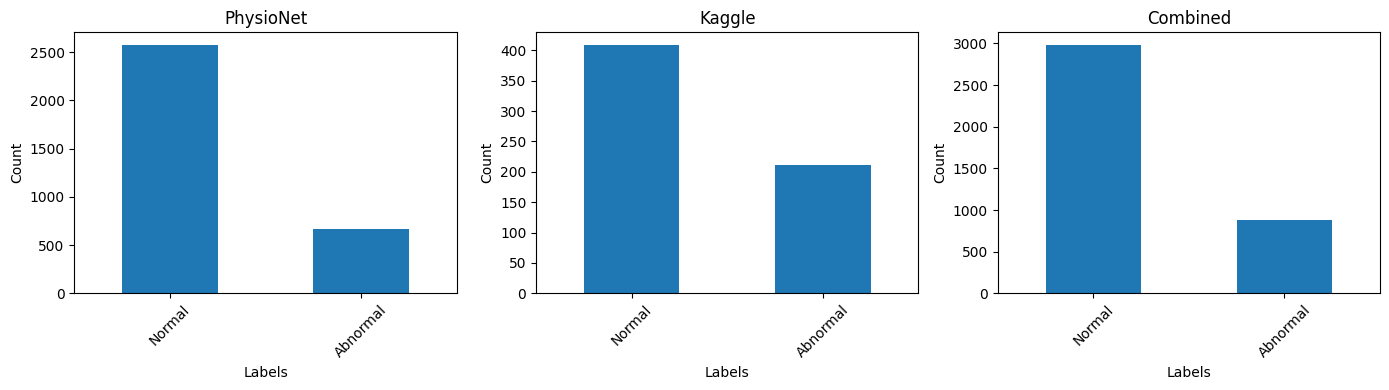

In [10]:
    # Run data loading
    all_dataset = load_and_validate_datasets(PHYSIONET_PATH, PHYSIONET_FOLDERS, KAGGLE_PATH)

In [10]:
# Cell 6: Audio Preprocessing and Augmentation
class AudioProcessor:
    def __init__(self):
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()
    
    def apply_augmentation(self, waveform, augment_prob=0.5):
        if np.random.random() < augment_prob:
            shift = int(np.random.uniform(-0.1, 0.1) * len(waveform))
            waveform = torch.roll(waveform, shifts=shift)
            if np.random.random() < 0.5:
                waveform += torch.randn_like(waveform) * 0.03
            if np.random.random() < 0.3:
                waveform *= np.random.uniform(0.8, 1.2)
            waveform = torch.clamp(waveform, -1.0, 1.0)
        return waveform

    def extract_features(self, waveform):
        if waveform.dim() == 1:
            waveform = waveform.unsqueeze(0)
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec).squeeze(0)
        current_width = mel_spec_db.shape[1]
        if current_width < FIXED_FRAMES:
            pad_width = FIXED_FRAMES - current_width
            mel_spec_db = F.pad(mel_spec_db, (0, pad_width))
        elif current_width > FIXED_FRAMES:
            mel_spec_db = mel_spec_db[:, :FIXED_FRAMES]
        return mel_spec_db

In [11]:
# Initialize audio processor
audio_processor = AudioProcessor()
print("Audio processor initialized successfully!")

Audio processor initialized successfully!


In [12]:
class HeartSoundDataset(Dataset):
    def __init__(self, data_list, audio_processor, augment=False, max_segments_per_file=3):
        self.data_list = data_list
        self.audio_processor = audio_processor
        self.augment = augment
        self.max_segments_per_file = max_segments_per_file
        self.processed_data = self._process_data()
        self.label_to_idx = {'Normal': 0, 'Abnormal': 1}

    def _process_data(self):
        segments = []
        for path, label in tqdm(self.data_list, desc="Processing audio files..."):
            waveform, sr = torchaudio.load(path)
            if sr != SAMPLE_RATE:
                resample = torchaudio.transforms.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
                waveform = resample(waveform)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
            waveform = waveform.squeeze()
            length = int(SAMPLE_RATE * SEGMENT_DURATION)
            step = length // 2
            for i in range(0, len(waveform) - length + 1, step):
                segment = waveform[i:i+length]
                if len(segment) < length:
                    continue
                segments.append((segment, label))
                if len(segments) >= self.max_segments_per_file * len(self.data_list):
                    break
        print(f"Total segments created: {len(segments)}")
        return segments

    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        waveform, label = self.processed_data[idx]
        if self.augment:
            waveform = self.audio_processor.apply_augmentation(waveform)
        features = self.audio_processor.extract_features(waveform)
        return features, torch.tensor(self.label_to_idx[label], dtype=torch.long)


In [13]:
class HeartSoundClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.attention = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=True)

        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, N_MELS, T)
        x = self.cnn(x)     # (B, 32, H, W)
        B, C, H, W = x.shape
        x = x.view(B, C, -1).transpose(1, 2)  # (B, Seq_len, Embed_dim)
        x, _ = self.attention(x, x, x)
        x = x.mean(dim=1)  # (B, 32)
        return self.fc(x)


In [14]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for data, target in tqdm(dataloader, desc="Training"):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == target).sum().item()
        total += target.size(0)

    return running_loss / len(dataloader), 100. * correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for data, target in tqdm(dataloader, desc="Validating"):
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == target).sum().item()
            total += target.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    return running_loss / len(dataloader), 100. * correct / total, all_preds, all_targets


In [16]:
def compute_class_weights(dataset):
    labels = [label for _, label in dataset.processed_data]
    counter = Counter(labels)

    # Make sure both classes exist
    normal_count = counter.get(0, 0)
    abnormal_count = counter.get(1, 0)
    total = normal_count + abnormal_count

    if normal_count == 0 or abnormal_count == 0:
        print("⚠️ Warning: One of the classes is missing in this fold. Using equal weights.")
        return torch.tensor([1.0, 1.0], dtype=torch.float32)

    weights = [total / normal_count, total / abnormal_count]
    return torch.tensor(weights, dtype=torch.float32)

def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=0.001, save_path="best_model.pth"):
    class_weights = compute_class_weights(train_loader.dataset).to(device)
    print(f"⚖️  Class Weights: {class_weights.tolist()}")

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    early_stopping = EarlyStopping(patience=20, min_delta=0.0001)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'learning_rates': []}

    print("🚀 Starting training...")
    for epoch in range(num_epochs):
        print(f"\n📅 Epoch {epoch+1}/{num_epochs}\n" + "-" * 50)
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(current_lr)

        print(f"🧠 Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"🧪 Val   Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")
        print(f"📉 LR adjusted to: {current_lr:.6f}")

        if early_stopping(val_loss, model):
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
            break

    torch.save(model.state_dict(), save_path)
    print(f"\n💾 Model saved to {save_path}")
    return history


In [17]:
def evaluate_model(model, loader, device, title="Evaluation"):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    print(f"\n📊 {title} Classification Report")
    print(classification_report(all_targets, all_preds, target_names=["Normal", "Abnormal"]))
    cm = confusion_matrix(all_targets, all_preds)

    import seaborn as sns
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} Confusion Matrix")
    plt.show()


In [18]:
def create_weighted_sampler(dataset):
    labels = [label for _, label in dataset.processed_data]
    class_counts = Counter(labels)
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in labels]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

def run_cross_validation(all_data, audio_processor, batch_size=16, num_epochs=50, num_folds=5):
    labels = [label for _, label in all_data]
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(all_data, labels)):
        print(f"\n========== Fold {fold+1}/{num_folds} ==========")
        train_data = [all_data[i] for i in train_idx]
        val_data = [all_data[i] for i in val_idx]

        train_dataset = HeartSoundDataset(train_data, audio_processor, augment=True)
        val_dataset = HeartSoundDataset(val_data, audio_processor, augment=False)

        train_sampler = create_weighted_sampler(train_dataset)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        model = HeartSoundClassifier().to(device)
        history = train_model(model, train_loader, val_loader, num_epochs=num_epochs, save_path=f"model_fold_{fold+1}.pth")
        evaluate_model(model, val_loader, device, title=f"Fold {fold+1}")
        results.append(history)

        print("Train class distribution:", Counter(label for _, label in train_dataset.processed_data))
        print("Val class distribution:", Counter(label for _, label in val_dataset.processed_data))


    return results



========== Fold 1/5 ==========


Processing audio files...: 100%|██████████████████████████████████████████████████| 3088/3088 [00:20<00:00, 152.73it/s]


Total segments created: 10839


Processing audio files...: 100%|████████████████████████████████████████████████████| 773/773 [00:05<00:00, 147.09it/s]


Total segments created: 2709
⚠️ Warning: One of the classes is missing in this fold. Using equal weights.
⚖️  Class Weights: [1.0, 1.0]
🚀 Starting training...

📅 Epoch 1/50
--------------------------------------------------


...

🧠 Train Loss: 0.2122 | Acc: 90.68%
🧪 Val   Loss: 0.3368 | Acc: 87.23%
📉 LR adjusted to: 0.000125

📅 Epoch 49/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 170/170 [00:10<00:00, 16.76it/s]


🧠 Train Loss: 0.2063 | Acc: 90.88%
🧪 Val   Loss: 0.3309 | Acc: 87.04%
📉 LR adjusted to: 0.000125

📅 Epoch 50/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 170/170 [00:10<00:00, 16.28it/s]


🧠 Train Loss: 0.2151 | Acc: 90.76%
🧪 Val   Loss: 0.3406 | Acc: 87.30%
📉 LR adjusted to: 0.000063

💾 Model saved to model_fold_1.pth

📊 Fold 1 Classification Report
              precision    recall  f1-score   support

      Normal       0.92      0.87      0.89      1646
    Abnormal       0.81      0.88      0.85      1063

    accuracy                           0.87      2709
   macro avg       0.87      0.87      0.87      2709
weighted avg       0.88      0.87      0.87      2709



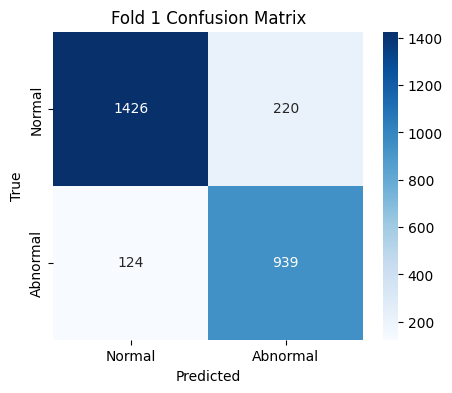

Train class distribution: Counter({'Normal': 6932, 'Abnormal': 3907})
Val class distribution: Counter({'Normal': 1646, 'Abnormal': 1063})

========== Fold 2/5 ==========


Processing audio files...: 100%|██████████████████████████████████████████████████| 3089/3089 [00:16<00:00, 183.45it/s]


Total segments created: 10817


Processing audio files...: 100%|████████████████████████████████████████████████████| 772/772 [00:04<00:00, 170.98it/s]


Total segments created: 2725
⚠️ Warning: One of the classes is missing in this fold. Using equal weights.
⚖️  Class Weights: [1.0, 1.0]
🚀 Starting training...

📅 Epoch 1/50
--------------------------------------------------


...

🧠 Train Loss: 0.2078 | Acc: 91.48%
🧪 Val   Loss: 0.3118 | Acc: 85.58%
📉 LR adjusted to: 0.000031

📅 Epoch 48/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 171/171 [00:10<00:00, 16.74it/s]


🧠 Train Loss: 0.2155 | Acc: 91.13%
🧪 Val   Loss: 0.3175 | Acc: 85.72%
📉 LR adjusted to: 0.000031

📅 Epoch 49/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 171/171 [00:10<00:00, 16.12it/s]


🧠 Train Loss: 0.2058 | Acc: 91.52%
🧪 Val   Loss: 0.3170 | Acc: 85.61%
📉 LR adjusted to: 0.000031

⛔ Early stopping triggered at epoch 49

💾 Model saved to model_fold_2.pth

📊 Fold 2 Classification Report
              precision    recall  f1-score   support

      Normal       0.90      0.86      0.88      1681
    Abnormal       0.79      0.85      0.82      1044

    accuracy                           0.86      2725
   macro avg       0.85      0.85      0.85      2725
weighted avg       0.86      0.86      0.86      2725



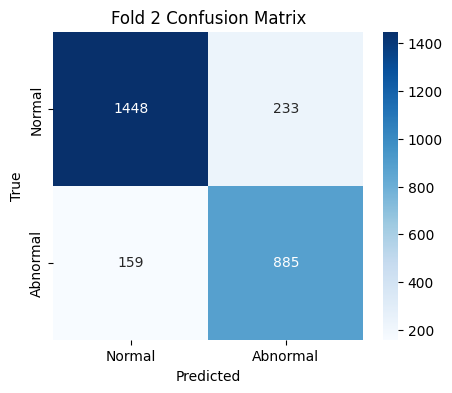

Train class distribution: Counter({'Normal': 6895, 'Abnormal': 3922})
Val class distribution: Counter({'Normal': 1681, 'Abnormal': 1044})

========== Fold 3/5 ==========


Processing audio files...: 100%|██████████████████████████████████████████████████| 3089/3089 [00:23<00:00, 130.65it/s]


Total segments created: 10865


Processing audio files...: 100%|████████████████████████████████████████████████████| 772/772 [00:06<00:00, 126.15it/s]


Total segments created: 2690
⚠️ Warning: One of the classes is missing in this fold. Using equal weights.
⚖️  Class Weights: [1.0, 1.0]
🚀 Starting training...

📅 Epoch 1/50
--------------------------------------------------


...

🧠 Train Loss: 0.2295 | Acc: 90.79%
🧪 Val   Loss: 0.2664 | Acc: 88.14%
📉 LR adjusted to: 0.000031

📅 Epoch 49/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 169/169 [00:10<00:00, 16.29it/s]


🧠 Train Loss: 0.2358 | Acc: 90.06%
🧪 Val   Loss: 0.2903 | Acc: 87.51%
📉 LR adjusted to: 0.000031

📅 Epoch 50/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 169/169 [00:09<00:00, 17.04it/s]


🧠 Train Loss: 0.2252 | Acc: 90.52%
🧪 Val   Loss: 0.2905 | Acc: 87.66%
📉 LR adjusted to: 0.000031

💾 Model saved to model_fold_3.pth

📊 Fold 3 Classification Report
              precision    recall  f1-score   support

      Normal       0.96      0.84      0.90      1719
    Abnormal       0.77      0.95      0.85       971

    accuracy                           0.88      2690
   macro avg       0.87      0.89      0.87      2690
weighted avg       0.89      0.88      0.88      2690



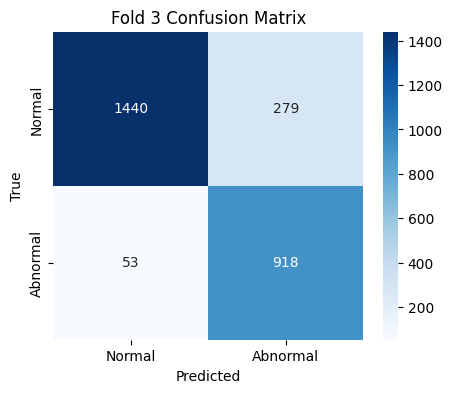

Train class distribution: Counter({'Normal': 6844, 'Abnormal': 4021})
Val class distribution: Counter({'Normal': 1719, 'Abnormal': 971})

========== Fold 4/5 ==========


Processing audio files...: 100%|██████████████████████████████████████████████████| 3089/3089 [00:15<00:00, 204.79it/s]


Total segments created: 10851


Processing audio files...: 100%|████████████████████████████████████████████████████| 772/772 [00:05<00:00, 146.29it/s]


Total segments created: 2692
⚠️ Warning: One of the classes is missing in this fold. Using equal weights.
⚖️  Class Weights: [1.0, 1.0]
🚀 Starting training...

📅 Epoch 1/50
--------------------------------------------------


...

🧠 Train Loss: 0.2282 | Acc: 90.50%
🧪 Val   Loss: 0.2661 | Acc: 88.08%
📉 LR adjusted to: 0.000031

📅 Epoch 49/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 169/169 [00:10<00:00, 16.24it/s]


🧠 Train Loss: 0.2358 | Acc: 90.24%
🧪 Val   Loss: 0.2362 | Acc: 89.08%
📉 LR adjusted to: 0.000031

📅 Epoch 50/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 169/169 [00:10<00:00, 16.54it/s]


🧠 Train Loss: 0.2294 | Acc: 90.37%
🧪 Val   Loss: 0.2359 | Acc: 89.12%
📉 LR adjusted to: 0.000031

💾 Model saved to model_fold_4.pth

📊 Fold 4 Classification Report
              precision    recall  f1-score   support

      Normal       0.93      0.90      0.92      1828
    Abnormal       0.81      0.86      0.84       864

    accuracy                           0.89      2692
   macro avg       0.87      0.88      0.88      2692
weighted avg       0.89      0.89      0.89      2692



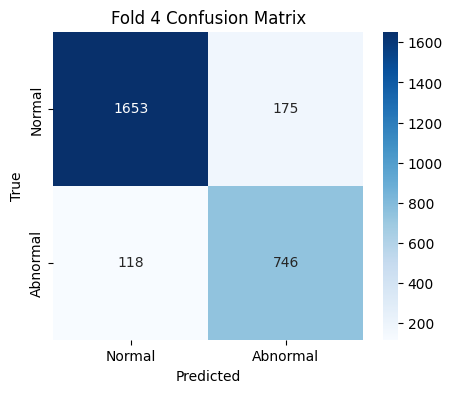

Train class distribution: Counter({'Normal': 6786, 'Abnormal': 4065})
Val class distribution: Counter({'Normal': 1828, 'Abnormal': 864})

========== Fold 5/5 ==========


Processing audio files...: 100%|██████████████████████████████████████████████████| 3089/3089 [00:18<00:00, 167.02it/s]


Total segments created: 10829


Processing audio files...: 100%|████████████████████████████████████████████████████| 772/772 [00:04<00:00, 192.11it/s]


Total segments created: 2722
⚠️ Warning: One of the classes is missing in this fold. Using equal weights.
⚖️  Class Weights: [1.0, 1.0]
🚀 Starting training...

📅 Epoch 1/50
--------------------------------------------------


...

🧠 Train Loss: 0.2346 | Acc: 90.13%
🧪 Val   Loss: 0.3129 | Acc: 86.77%
📉 LR adjusted to: 0.000500

📅 Epoch 49/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 171/171 [00:10<00:00, 16.46it/s]


🧠 Train Loss: 0.2335 | Acc: 89.96%
🧪 Val   Loss: 0.2437 | Acc: 90.08%
📉 LR adjusted to: 0.000500

📅 Epoch 50/50
--------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 171/171 [00:10<00:00, 16.31it/s]


🧠 Train Loss: 0.2338 | Acc: 89.88%
🧪 Val   Loss: 0.2698 | Acc: 89.75%
📉 LR adjusted to: 0.000500

💾 Model saved to model_fold_5.pth

📊 Fold 5 Classification Report
              precision    recall  f1-score   support

      Normal       0.93      0.90      0.92      1682
    Abnormal       0.85      0.89      0.87      1040

    accuracy                           0.90      2722
   macro avg       0.89      0.90      0.89      2722
weighted avg       0.90      0.90      0.90      2722



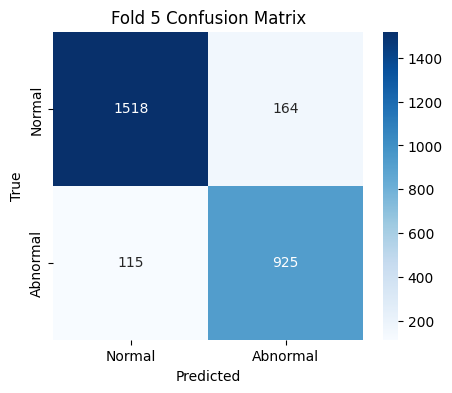

Train class distribution: Counter({'Normal': 6890, 'Abnormal': 3939})
Val class distribution: Counter({'Normal': 1682, 'Abnormal': 1040})


In [36]:
# Prepare data and start training
audio_processor = AudioProcessor()

# Assuming you already have all_dataset = [(path, label), ...] loaded from PhysioNet + Kaggle
cv_results = run_cross_validation(all_dataset, audio_processor, batch_size=16, num_epochs=50)


In [40]:
import torch
import pickle

# 1. Define the model architecture (must match training)
model = HeartSoundClassifier().to(device)

# 2. Load the trained weights from fold 5
model.load_state_dict(torch.load("model_fold_5.pth", map_location=device))
model.eval()

# 3. Pickle and save the entire model object
with open("heart_sound_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model successfully exported as 'heart_sound_model.pkl'")


✅ Model successfully exported as 'heart_sound_model.pkl'


In [41]:
import torch
import torchaudio
import numpy as np
import pickle

# 1. Load pickled model
with open("heart_sound_model.pkl", "rb") as f:
    model = pickle.load(f)
model.to(device).eval()

# 2. Reinstantiate your audio processor
audio_processor = AudioProcessor()

# 3. Prediction function
def predict_heartbeat(wav_path, model, audio_processor, device):
    # Load and resample
    waveform, sr = torchaudio.load(wav_path)
    if sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
        waveform = resampler(waveform)
    # Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    waveform = waveform.squeeze()
    
    # Take a single SEGMENT_DURATION slice (pad or crop)
    target_len = int(SAMPLE_RATE * SEGMENT_DURATION)
    if waveform.numel() < target_len:
        waveform = torch.nn.functional.pad(waveform, (0, target_len - waveform.numel()))
    else:
        waveform = waveform[:target_len]
    
    # Extract features
    features = audio_processor.extract_features(waveform)
    features = features.unsqueeze(0).to(device)  # shape (1, N_MELS, T)
    
    # Forward pass
    with torch.no_grad():
        logits = model(features)
        # If model returns (out, attn), unpack: logits = model(features)[0]
        if isinstance(logits, tuple):
            logits = logits[0]
        prob = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(prob)
    
    label = "Normal" if pred == 0 else "Abnormal"
    confidence = float(prob[pred])
    return label, confidence

In [42]:
# 4. Example usage
test_file = "S4 Gallop Recording & Waveform  Eko Health.wav"
label, conf = predict_heartbeat(test_file, model, audio_processor, device)
print(f"Prediction: {label}  (confidence: {conf:.3f})")

Prediction: Abnormal  (confidence: 0.957)


Accuracy: 0.5116
Precision: 0.5069
Recall: 0.9669
F1 Score: 0.6651
AUC: 0.6215


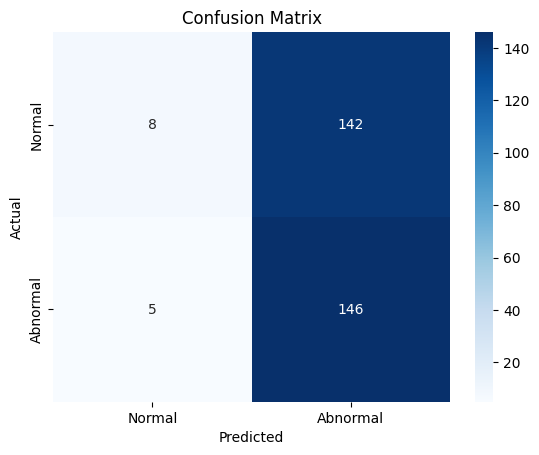

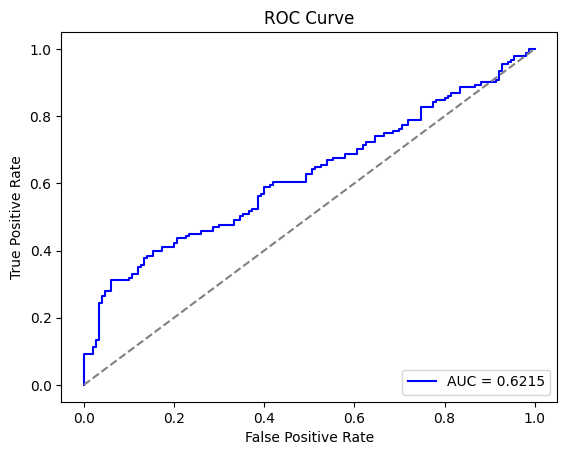

In [19]:
import torch
import torchaudio
import numpy as np
import pickle
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load pickled model
with open("cnn_model_paths/heart_sound_model.pkl", "rb") as f:
    model = pickle.load(f)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# 2. Reinstantiate your audio processor
audio_processor = AudioProcessor()

# 3. Load validation data
VALIDATION_PATH = r"C:\Users\MAXIMUS8\Desktop\Heart\classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0\validation"
REFERENCE_CSV = os.path.join(VALIDATION_PATH, "REFERENCE.csv")
SAMPLE_RATE = 4000
SEGMENT_DURATION = 5.0

def load_validation_data(validation_path, reference_csv):
    # Load the reference CSV
    df = pd.read_csv(reference_csv, header=None, names=["file_name", "label"])
    
    # Map labels: 1 -> Abnormal, -1 -> Normal
    label_mapping = {1: 1, -1: 0}  # 1 = Abnormal, 0 = Normal
    df["label"] = df["label"].map(label_mapping)
    
    # Create a list of (file_path, label) tuples
    data_list = [
        (os.path.join(validation_path, f"{row['file_name']}.wav"), row["label"])
        for _, row in df.iterrows()
    ]
    return data_list

validation_data = load_validation_data(VALIDATION_PATH, REFERENCE_CSV)

# 4. Prediction function
def predict_heartbeat(wav_path, model, audio_processor, device):
    # Load and resample
    waveform, sr = torchaudio.load(wav_path)
    if sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
        waveform = resampler(waveform)
    # Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    waveform = waveform.squeeze()
    
    # Take a single SEGMENT_DURATION slice (pad or crop)
    target_len = int(SAMPLE_RATE * SEGMENT_DURATION)
    if waveform.numel() < target_len:
        waveform = torch.nn.functional.pad(waveform, (0, target_len - waveform.numel()))
    else:
        waveform = waveform[:target_len]
    
    # Extract features
    features = audio_processor.extract_features(waveform)
    features = features.unsqueeze(0).to(device)  # shape (1, N_MELS, T)
    
    # Forward pass
    with torch.no_grad():
        logits = model(features)
        if isinstance(logits, tuple):  # If model returns (logits, attention), unpack
            logits = logits[0]
        prob = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(prob)
    
    return pred, prob

# 5. Evaluate the model on the validation dataset
all_targets = []
all_predictions = []
all_probabilities = []

for file_path, label in validation_data:
    pred, prob = predict_heartbeat(file_path, model, audio_processor, device)
    all_predictions.append(pred)
    all_targets.append(label)
    all_probabilities.append(prob[1])  # Probability of class 1 (Abnormal)

# 6. Calculate metrics
accuracy = accuracy_score(all_targets, all_predictions)
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_predictions, average="binary")
auc = roc_auc_score(all_targets, all_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# 7. Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names=["Normal", "Abnormal"]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(all_targets, all_predictions)

# 8. Plot ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_targets, all_probabilities)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()